In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models
from sklearn.metrics import confusion_matrix
from PIL import Image
import collections
import seaborn as sns

In [2]:
# Φορτώνουμε το pre-trained MobileNetV2 με βάρη από ImageNet.
# Αντικαθιστούμε το τελευταίο classifier layer για 3 κλάσεις (High/Low/NoWaste).
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(in_features=1280, out_features=3)

In [3]:
# DATA AUGMENTATION - Ίδιο με το RN50_WL_TK-Means50 για δίκαιη σύγκριση
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, hue=0.2, saturation=0.3),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

In [4]:
# DATASETS - Ίδιο dataset με το RN50_WL_TK-Means50
train_dataset = torchvision.datasets.ImageFolder(
    root="C:/Users/panag/Desktop/Thesis/Datasets/KMeans_Dataset_with_ResNet50/train",
    transform=transform_train)

test_dataset = torchvision.datasets.ImageFolder(
    root="C:/Users/panag/Desktop/Thesis/Datasets/KMeans_Dataset_with_ResNet50/test",
    transform=transform_test)

In [5]:
# Train-Test Loaders
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=32, num_workers=2, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=32, num_workers=2, shuffle=False)

In [6]:
# Υπολογισμός Class Weights - Ίδιος τρόπος με το RN50_WL_TK-Means50
class_counts = collections.Counter(train_dataset.targets)
for cls_idx, count in sorted(class_counts.items()):
    cls_name = train_dataset.classes[cls_idx]
    print(f"  {cls_name}: {count} pictures")

total_samples = len(train_dataset)
class_weights = torch.tensor([
    total_samples / class_counts[i]
    for i in range(len(train_dataset.classes))], dtype=torch.float)

print(f"\nClass weights: {class_weights}")

  High: 803 pictures
  Low: 939 pictures
  NoWaste: 705 pictures

Class weights: tensor([3.0473, 2.6060, 3.4709])


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
# CrossEntropyLoss ΜΕ class weights (Weight Loss)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
model = model.to(device)

In [9]:
# FROZEN LAYERS
# Στο ResNet50 WL: frozen layer1,layer2 / trainable: layer3, layer4, fc
# Στο MobileNetV2: frozen features[0:14] / trainable: features[14:18] + classifier
for param in model.parameters():
    param.requires_grad = False

for param in model.features[14].parameters():
    param.requires_grad = True
for param in model.features[15].parameters():
    param.requires_grad = True
for param in model.features[16].parameters():
    param.requires_grad = True
for param in model.features[17].parameters():
    param.requires_grad = True
for param in model.features[18].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

In [10]:
# Optimizer + Scheduler - Ίδιο με το RN50_WL_TK-Means50
optimizer = optim.Adam(
    list(model.features[14].parameters()) +
    list(model.features[15].parameters()) +
    list(model.features[16].parameters()) +
    list(model.features[17].parameters()) +
    list(model.features[18].parameters()) +
    list(model.classifier.parameters()),
    lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5)

In [11]:
# TRAINING LOOP - Ίδιο με το RN50_WL_TK-Means50
num_epoch = 10
best_accuracy = 0.0
worst_accuracy = 100.0
best_cm = None
worst_cm = None
best_epoch = 0
worst_epoch = 0

for epoch in range(num_epoch):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{num_epoch}, Loss: {avg_loss:.4f}')

    # Evaluation
    model.eval()
    test_loss = 0.0
    correct = 0.0
    total = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_test_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f'Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy:.2f}%\n')

    # Scheduler step
    scheduler.step(avg_test_loss)

    cm = confusion_matrix(all_targets, all_predictions)
    print("Confusion Matrix:")
    print(cm)
    print("-" * 40)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_cm = cm.copy()
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'MNV2_WL_TK-Means50.pth')
        print(f'New best model saved! Accuracy: {best_accuracy:.2f}%\n')

    if accuracy < worst_accuracy:
        worst_accuracy = accuracy
        worst_cm = cm.copy()
        worst_epoch = epoch + 1

Epoch 1/10, Loss: 0.6099
Test Loss: 0.4792, Test Accuracy: 84.97%

Confusion Matrix:
[[187  21   8]
 [  1 204  22]
 [ 35   5 129]]
----------------------------------------
New best model saved! Accuracy: 84.97%

Epoch 2/10, Loss: 0.4540
Test Loss: 0.3857, Test Accuracy: 84.80%

Confusion Matrix:
[[164  12  40]
 [  3 202  22]
 [ 12   4 153]]
----------------------------------------
Epoch 3/10, Loss: 0.4279
Test Loss: 0.5045, Test Accuracy: 87.42%

Confusion Matrix:
[[179  27  10]
 [  1 222   4]
 [ 17  18 134]]
----------------------------------------
New best model saved! Accuracy: 87.42%

Epoch 4/10, Loss: 0.4195
Test Loss: 0.3250, Test Accuracy: 88.56%

Confusion Matrix:
[[195  10  11]
 [ 11 209   7]
 [ 20  11 138]]
----------------------------------------
New best model saved! Accuracy: 88.56%

Epoch 5/10, Loss: 0.3890
Test Loss: 0.4020, Test Accuracy: 88.07%

Confusion Matrix:
[[198   9   9]
 [ 11 207   9]
 [ 29   6 134]]
----------------------------------------
Epoch 6/10, Loss: 0.

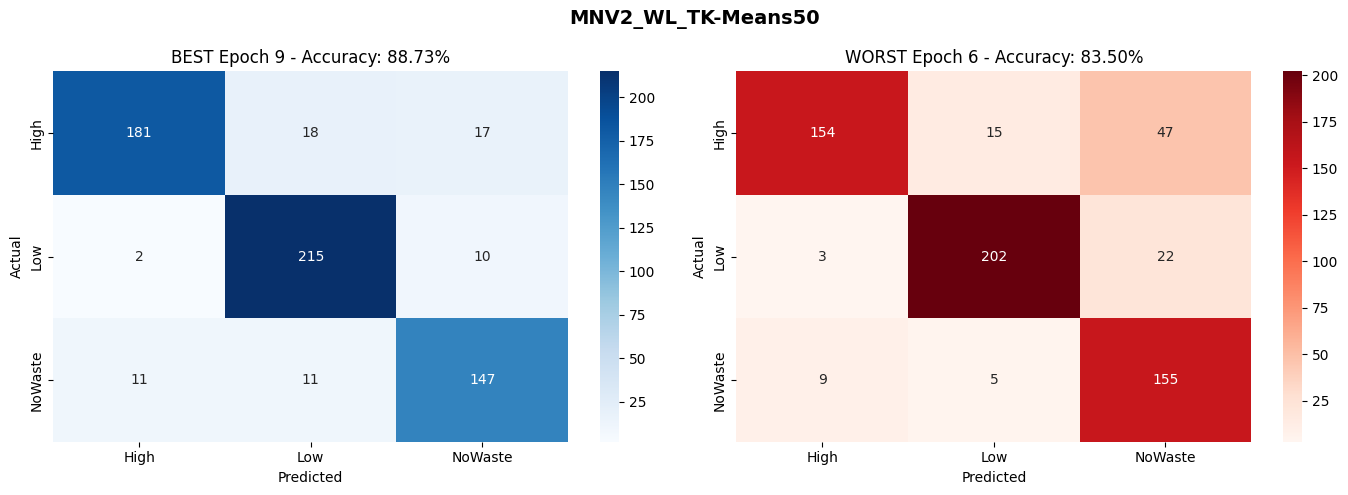

Αποθηκεύτηκε σε MNV2_WL_TKMeans50_confusion_matrices.png


In [12]:
# Confusion Matrix visualization (Best & Worst epoch)
classes = ['High', 'Low', 'NoWaste']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes)
axes[0].set_title(f'BEST Epoch {best_epoch} - Accuracy: {best_accuracy:.2f}%')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(worst_cm, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=classes, yticklabels=classes)
axes[1].set_title(f'WORST Epoch {worst_epoch} - Accuracy: {worst_accuracy:.2f}%')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('MNV2_WL_TK-Means50', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('MNV2_WL_TKMeans50_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε σε MNV2_WL_TKMeans50_confusion_matrices.png')

In [13]:
def predict_confidence(image_path):
    model.load_state_dict(torch.load('MNV2_WL_TK-Means50.pth'))
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image = transform_test(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted_class = torch.max(probabilities, dim=1)

        prob = confidence.item()
        predicted = predicted_class.item()
        raw_confidence = int(prob * 100)

        if predicted == 0:        # High  → ≥85%
            confidence_score = max(85, raw_confidence)
        elif predicted == 1:      # Low   → 65-84%
            confidence_score = max(65, min(84, raw_confidence))
        else:                     # NoWaste → ≤64%
            confidence_score = min(64, raw_confidence)

        class_names = {0: 'High', 1: 'Low', 2: 'NoWaste'}

        print(f'Κατηγορία: {class_names[predicted]}')
        print(f'Confidence: {confidence_score}%')
        print(f'Raw Softmax: {raw_confidence}%')
        print('---')

    return class_names[predicted], confidence_score


# Δοκιμή
class_name, confidence = predict_confidence("C:/Users/panag/Desktop/full.avif")
print(f'Κατηγορία: {class_name}, Confidence: {confidence}%')

Κατηγορία: High
Confidence: 85%
Raw Softmax: 59%
---
Κατηγορία: High, Confidence: 85%
